# 15 — The stress tensor

The stress is `sigma_ab = -(1/Omega) dE/d(epsilon_ab)`: how the total energy responds to
deforming the cell. Here it comes from **one `jax.grad`** of the energy written as a
function of a strain at frozen wavefunctions — the same construction the forces use
(notebook `09`) with the cell in place of the atoms — so no expression is derived for the
kinetic, Hartree, local, exchange-correlation, augmentation or Ewald contributions.

On the five silicon references generated for this phase it reproduces `pw.x` to
**≤2.7e-7 Ry/bohr³**, and every one of the seven terms `pw.x` prints separately matches to
the precision it prints them in.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import Calculation, run_scf
from pypresso.stress import compute_stress, format_stress
from pypresso.system import build_system
from pypresso.units import RY_TO_KBAR

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")


def converged(name, conv_thr=1e-10):
    system = build_system(read_pw_input(CASES / f"{name}.in"))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    calculation = Calculation(system, pseudos)
    result = run_scf(system, pseudos, calculation=calculation,
                     conv_thr=conv_thr, max_iterations=100)
    return system, calculation, result

## Run it

`si2-nc-sheared.in` is the two-atom silicon cell with `a3` tilted by 4% in the *xy*
plane. The tilt is deliberate: on the ideal cubic cell the stress is a multiple of the
identity and a tensor with the wrong shear components looks perfect. Here the crystal has
two symmetry operations and every entry of `sigma` is free.

In [2]:
system, calculation, result = converged("si2-nc-sheared")
stress = compute_stress(calculation, result, terms=True)

print(f"E = {result.total_energy:.8f} Ry")
print(format_stress(stress))

E = -15.78818221 Ry
          total   stress  (Ry/bohr**3)                   (kbar)     P=      -31.13
  -0.00050526  -0.00000855  -0.00013061          -74.33       -1.26      -19.21
  -0.00000855   0.00002509  -0.00014744           -1.26        3.69      -21.69
  -0.00013061  -0.00014744  -0.00015475          -19.21      -21.69      -22.76


## The equation of state

The pressure is a thermodynamic derivative, `P = -dE/dV`, and nothing in the calculation
above knows that: `sigma` comes from a gradient taken at **one** volume with the
wavefunctions frozen. Computing `E(V)` by re-converging the SCF at a series of lattice
constants and differentiating the curve is therefore an independent check — and the one
that says the gradient is the derivative of the energy the SCF actually minimises.

The cutoff matters here and nowhere else in this notebook. Expanding the cell at fixed
`ecutwfc` lets *more* plane waves inside the cutoff, so the basis improves as the volume
grows and the energy falls for a reason that is not physics. That artefact is the **Pulay
stress**; at the test suite's `ecutwfc = 12` it is larger than the pressure itself, so the
curve below is computed at 40 Ry.

In [3]:
import equinox as eqx
import jax.numpy as jnp

ECUT = 40.0
ALAT = 10.20


def at_scale(scale, ecutwfc=ECUT):
    """Silicon at `alat * scale`, converged, with the sphere reselected.

    The **lattice parameter** is what is scaled, not `cell.at`. Every derived
    quantity then follows -- the reciprocal cell, the FFT grid, and above all
    the k-points, which are stored in units of `2 pi / alat` and would
    otherwise stay where they were in *cartesian* space while the zone moved
    underneath them. That is the trap of this phase and it is silent.
    """
    pwin = read_pw_input(CASES / "si2-nc-stress.in")
    pwin.namelists["system"]["celldm"] = {(1,): ALAT * scale}
    pwin.namelists["system"]["ecutwfc"] = ecutwfc
    pwin.namelists["system"]["ecutrho"] = 4.0 * ecutwfc
    system = build_system(pwin)
    # ...on the *ideal* sites, so the curve is an equation of state and not a
    # mixture of one with a displaced atom relaxing.
    positions = np.array(system.structure.positions)
    positions[1] = np.array([0.25, 0.25, 0.25]) * float(system.cell.alat)
    system = eqx.tree_at(lambda s: s.structure.positions, system,
                         jnp.asarray(positions))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    calculation = Calculation(system, pseudos)
    result = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-10,
                     max_iterations=120)
    return calculation, result


scales = np.linspace(0.96, 1.04, 7)
volumes, energies, pressures = [], [], []
for scale in scales:
    calc, res = at_scale(scale)
    volumes.append(float(calc.system.cell.volume))
    energies.append(res.total_energy)
    pressures.append(compute_stress(calc, res).pressure_kbar)

volumes = np.array(volumes)
energies = np.array(energies)
pressures = np.array(pressures)

max |tr sigma/3 + dE/dV| over the interior points: 2.58 kbar
...against a pressure that spans -83 to 161 kbar


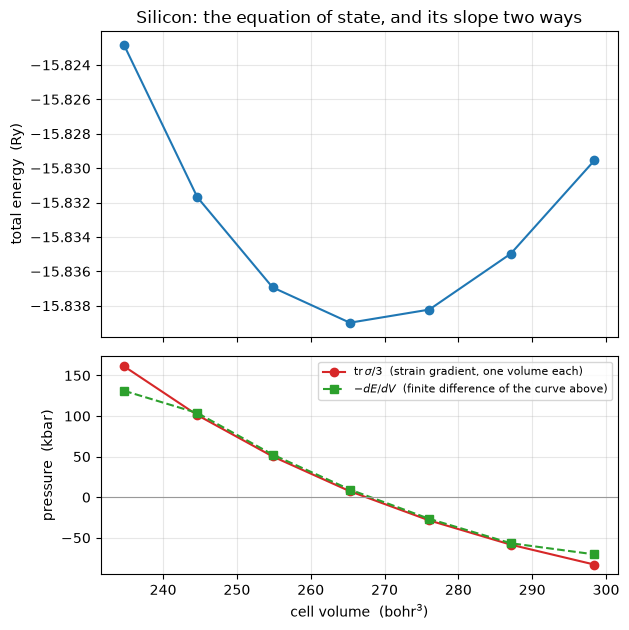

In [4]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(6.4, 6.4), sharex=True,
                                  gridspec_kw={"height_ratios": [1.4, 1]})

top.plot(volumes, energies, "o-", color="#1f77b4")
top.set_ylabel("total energy  (Ry)")
top.set_title("Silicon: the equation of state, and its slope two ways")
top.grid(alpha=0.3)

# -dE/dV from central differences of the curve above, at the interior points.
numerical = -np.gradient(energies, volumes) * RY_TO_KBAR

bottom.plot(volumes, pressures, "o-", color="#d62728",
            label=r"$\mathrm{tr}\,\sigma/3$  (strain gradient, one volume each)")
bottom.plot(volumes, numerical, "s--", color="#2ca02c",
            label=r"$-dE/dV$  (finite difference of the curve above)")
bottom.axhline(0.0, color="0.6", lw=0.8)
bottom.set_xlabel(r"cell volume  (bohr$^3$)")
bottom.set_ylabel("pressure  (kbar)")
bottom.legend(fontsize=8)
bottom.grid(alpha=0.3)
fig.tight_layout()

interior = slice(1, -1)
residue = np.abs(pressures[interior] - numerical[interior]).max()
print(f"max |tr sigma/3 + dE/dV| over the interior points: {residue:.2f} kbar")
print(f"...against a pressure that spans {pressures.min():.0f} to {pressures.max():.0f} kbar")

The two curves are the same function computed two ways that share nothing: one is a
derivative of the code, the other a derivative of its output. What separates them is the
Pulay stress, and it is measured: 1.1 kbar at 40 Ry, 44 kbar at 12, 0.11 at 60.

The volume where the red curve crosses zero is LDA silicon's equilibrium, which is what a
`vc-relax` would find. That is deliberately **not** implemented (`PLAN.md`, P11): a moving
cell would invalidate the rule that the FFT grid and the symmetry group are fixed once for
the whole run.

## Against Quantum ESPRESSO

Five references, generated with the vendored `pw.x`, each adding one thing to the one
before: a displaced cell, a sheared one, ultrasoft, PAW, and PBE.

In [5]:
rows = []
for case in ["si2-nc-stress", "si2-nc-sheared", "si2-us-stress",
             "si2-paw-stress", "si2-us-pbe-stress"]:
    reference = read_qe_output(CASES / f"reference.out.{case}")
    _, calc, res = converged(case)
    ours = compute_stress(calc, res)
    rows.append((
        case,
        ours.pressure_kbar,
        reference.pressure,
        np.abs(ours.tensor - np.asarray(reference.stress)).max(),
    ))

print(f"{'case':<20} {'P ours (kbar)':>14} {'P QE (kbar)':>12} {'max |dsigma|':>14}")
for name, mine, theirs, diff in rows:
    print(f"{name:<20} {mine:>14.2f} {theirs:>12.2f} {diff:>14.2e}")

case                  P ours (kbar)  P QE (kbar)   max |dsigma|
si2-nc-stress                -23.58       -23.58       4.31e-08
si2-nc-sheared               -31.13       -31.13       1.30e-08
si2-us-stress                 10.53        10.53       2.18e-07
si2-paw-stress                10.95        10.95       2.19e-07
si2-us-pbe-stress             47.08        47.08       2.68e-07


## How it works

The whole method is one function. `Calculation.at_strain(eps)` rebuilds every
cell-dependent array — the reciprocal lattice from the stored **Miller indices**, the
radial form factors against the moved `|G|`, the projectors, the augmentation charge, the
Ewald images — as a *traced* function of the strain; the energy is then evaluated at frozen
wavefunctions, occupations and eigenvalues, and `jax.grad` does the rest.

Two things make the partial derivative the total one. Stationarity at the SCF solution,
which is what lets the wavefunctions be frozen at all; and the fact that the frozen
quantity is the **coefficient vector**, not the wavefunction — a strain moves the plane
waves with the cell, so holding the coefficients fixed holds the state fixed in *crystal*
coordinates, which is the variational parameter the SCF minimised over.

Because the energy is written down once and differentiated, the decomposition comes free:
differentiate each term instead of their sum and the tensor arrives term by term.

In [6]:
for name, tensor in sorted(stress.terms.items()):
    if np.abs(tensor).max() < 1e-12:
        continue
    print(f"{name:>10}  diag(kbar) = "
          + "  ".join(f"{v * RY_TO_KBAR:9.2f}" for v in np.diag(tensor)))
print(f"{'total':>10}  diag(kbar) = "
      + "  ".join(f"{v * RY_TO_KBAR:9.2f}" for v in np.diag(stress.tensor)))

reference = read_qe_output(CASES / "reference.out.si2-nc-sheared")
worst = max(
    np.abs(stress.terms[ours] - np.asarray(reference.stress_terms[qe])).max()
    for qe, ours in [("kinetic", "kinetic"), ("local", "local"),
                     ("hartree", "hartree"), ("ewald", "ewald"),
                     ("nonlocal", "nonlocal")]
)
print(f"\nworst per-term disagreement with pw.x: {worst:.1e} Ry/bohr^3 "
      f"({worst * RY_TO_KBAR:.3f} kbar, which is how finely pw.x prints them)")

     ewald  diag(kbar) =  -2965.97   -3292.10   -3124.54
   hartree  diag(kbar) =    225.90     168.00     201.72
   kinetic  diag(kbar) =   2216.41    2308.48    2278.52
     local  diag(kbar) =  -1594.37   -1198.47   -1410.62
  nonlocal  diag(kbar) =   2854.30    2828.38    2842.76
        xc  diag(kbar) =   -810.60    -810.60    -810.60
     total  diag(kbar) =    -74.33       3.69     -22.76

worst per-term disagreement with pw.x: 3.8e-08 Ry/bohr^3 (0.006 kbar, which is how finely pw.x prints them)


---

`PLAN.md` §3, **P11** has the phase entry: what was built, the numbers, and the
transcription traps — the coordinate singularity in the spherical harmonics that only a
cell derivative reaches, the k-points that must follow the reciprocal cell, and the Pulay
stress measured against the cutoff.

`tests/regression/test_stress.py` and `tests/unit/test_stress_machinery.py` are the checks
this notebook illustrates.
